# Twitter Sentiment Analysis of Apple and Google Products

Author: Dorcas Ndambuki.

## **1. BUSINESS UNDERSTANDING**
Apple and Google receive thousands of tweets discussing their products. Monitoring customer sentiment manually is inefficient and difficult to scale.

# 1.1.Business Context
 Apple and Google operate in a highly competitive, fast-paced consumer tech market. Customer sentiment on social media shifts rapidly in response to product launches, software updates, and public relations events.

# 1.2 Business Problem
Apple and Google receive thousands of Tweets/public opinions daily discussing their products and services on Social Media. Brand managers cannot manually monitor the thousands of tweets as is The goal of this project is to build a machine learning model capable of automatically classifying tweet sentiment as positive, negative, or neutral.


# 1.3 Stakeholders
These are the people who will use or benefit from the results of this model ie Business stakeholders use the results to make decisions,Technical Stakeholders who build, deploy, and maintain the data systems and infrastructure or End-Users who interact with the model's output on a daily basis to do their jobs.

Brand Managers (Apple & Google)- Protect and grow the reputation of specific product lines.

Marketing Executives-  Design advertising campaigns and launch new products.

Customer Experience Executives-Oversee the entire customer journey and ensure overall satisfaction.

Business Executives-Make high-level strategic decisions, allocate budgets, and report to investors.

Product Support Teams-Resolve technical issues and assist customers directly.



# 1.4 Business Questions

Key Questions

1.Can tweet sentiment be predicted accurately?

2.Which words most strongly drive sentiment?

3.What themes appear in negative feedback?

4.How can Apple and Google use these insights?

# 1.5 Success Metric Selection

* **Primary metric**
    * Macro Recall

* **Secondary metrics**
    * Macro F1
    * Accuracy

## **2. DATA UNDERSTANDING**
# 2.1 Data Source

The dataset used in this project is the **Twitter Product Sentiment Dataset**, originally compiled by CrowdFlower and made available via data.world. It contains Tweets related to Apple and Google products and each Tweet was labelled according to its sentiment.


# 2.2 Dataset Dimensions
Number of observations (rows) before cleaning: ~9,000+ Tweets and 3 columns sentimentally labelled.

### Dataset Variables

| Variable | Description |
|----------|-------------|
| tweet_text | The full text content of the tweet |
| emotion_in_tweet_is_directed_at | The specific product or brand mentioned (e.g., iPhone, Google Pixel) |
| is_there_an_emotion_directed_at_a_brand_or_product | The sentiment label assigned to the tweet |

### Sentiment Distribution

| Sentiment | Count | Percentage (%) |
|-----------|-------|----------------|
| No emotion toward brand or product | 5389 | 59.3 |
| Positive emotion | 2978 | 32.8 |
| Negative emotion | 570 | 6.3 |
| I can't tell | 156 | 1.7 |
| **Total** | **9093** | **100.0** |

#### Key Observation
The dataset is highly imbalanced. The majority class ("no emotion") accounts for nearly 60% of all tweets, while negative sentiment represents only about 6% of the data.

Because of this imbalance, accuracy would be a misleading performance metric. A naive model predicting only "no emotion" would achieve high accuracy but fail to detect meaningful positive or negative feedback. Therefore, Macro Recall is selected as the primary evaluation metric With Macro F1 and Accuracy as secondary metrics.

### Import the Required Libraries

In [49]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import re
from collections import Counter
from nltk.corpus import stopwords, wordnet
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Moringa
[nltk_data]     School\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Moringa
[nltk_data]     School\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Moringa
[nltk_data]     School\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 2.3 Loading the dataset


In [50]:
df = pd.read_csv('data/twitter_sentiment.csv', encoding='unicode_escape')

df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [51]:
df.shape

(9093, 3)

In [76]:
# Rename columns for cleaner coding access
df.rename(columns={
    'tweet_text': 'tweet',
    'emotion_in_tweet_is_directed_at': 'target_brand',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
}, inplace=True)

## **3. EXPLORATORY DATA ANALYSIS**

Exploratory Data Analysis (EDA) is necessary to understand the underlying structure, class balance, and linguistic patterns in the dataset. These insights guided subsequent preprocessing and modeling decisions.

Visualizations:
To better understand the data, the following visualization was created:
* Sentiment distribution chart	Displays class imbalance visually and confirms data quality

### 3.1 Exploring the dataset

In [77]:
#Eplore the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9092 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       9092 non-null   object
 1   product    3291 non-null   object
 2   sentiment  9092 non-null   object
dtypes: object(3)
memory usage: 604.1+ KB


In [78]:
# Check missing values
df.isnull().sum()

text            0
product      5801
sentiment       0
dtype: int64

In [79]:
# Check for duplicates
df.duplicated().sum()

22

In [80]:
# Check the distribution of sentiments
df['sentiment'].value_counts()

No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: sentiment, dtype: int64

### 3.2 Visualize the distribution of sentiment labels

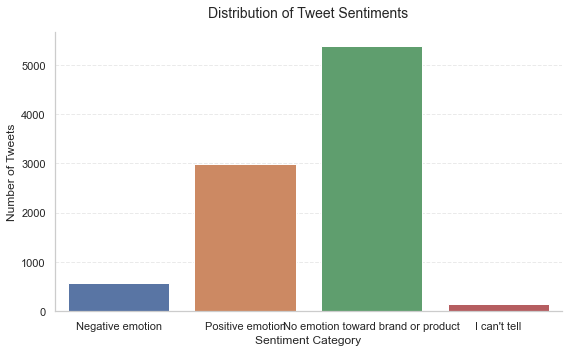

In [67]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='sentiment')

# Improve readability
plt.title('Distribution of Tweet Sentiments', fontsize=14, pad=15)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

### Sentiment Distribution Insight

The dataset shows a clear class imbalance. The majority of tweets express positive sentiment toward the brands, while negative sentiment is significantly underrepresented.

This imbalance is important for modeling because accuracy alone would be misleading. A model could achieve high accuracy by over-predicting the dominant positive class.

Therefore, evaluation metrics such as Macro Recall will be prioritized to ensure that minority classes, especially negative sentiment, are correctly identified.

Additionally, the presence of ambiguous labels ("I can't tell") introduces noise into the dataset and may affect classification performance.

In [85]:
df.columns = ['tweet', 'target_brand', 'sentiment']

In [86]:
# Check the distribution of target brands
df['target_brand'].value_counts()

iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: target_brand, dtype: int64

### 3.3 Visualize the distribution of target brands

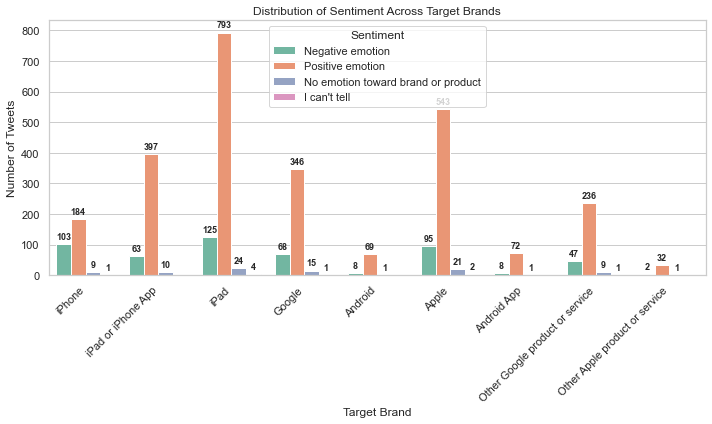

In [90]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='target_brand',
    hue='sentiment',
    palette='Set2'
)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only label bars that actually have data
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold',
            xytext=(0, 3), 
            textcoords='offset points'
        )

plt.title('Distribution of Sentiment Across Target Brands')
plt.xlabel('Target Brand')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

### Key Insights

- Positive sentiment dominates everywhere-indicating overall favorable brand perception.
- No emotions andIcant tell categories are consistently small across all brands indicating clear,strong opinions
- Negative sentiment exists but is much smaller compared to positive,but still doesnt outweigh the positives.
- The dataset is strongly positive on sentiment distribution and differs by brand, suggesting varying levels of customer satisfaction and engagement.

In [91]:
# Check the frequency of words in the tweets
all_words = ' '.join(df['tweet'].dropna()).split()

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,@mention,6703
1,{link},4255
2,#sxsw,4013
3,the,3887
4,#SXSW,3643
5,to,3496
6,RT,2883
7,at,2842
8,for,2432
9,a,2158


### 3.4 Visualize frequency of words in the tweets

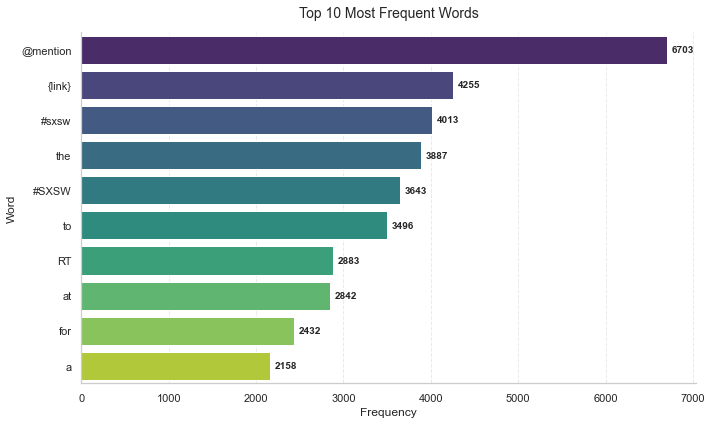

In [98]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word',
    palette='viridis'
)
# Add frequency labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.), 
            va='center', 
            ha='left', 
            fontsize=10, 
            fontweight='bold',
            xytext=(5, 0), 
            textcoords='offset points'
        )
plt.title('Top 10 Most Frequent Words', fontsize=14, pad=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

### Key EDA Insights

This frequency distribution reveals that raw, uncleaned text is critically dominated by structural noise rather than sentiment signal:
1. **Stop Word Dominance:** Standard English articles ('the', 'to', 'at') drown out emotional descriptors.
2. **Platform Artifacts:** Metadata placeholders like `@mention`, `{link}`, and `RT` inflate feature dimensionality without providing brand insight.
3. **Case Discrepancies:** The separation of `#the sxsw` and `#SXSW` proves that without aggressive lowercase standardization, feature weights will be split and diluted.

**Conclusion:** This justifies our custom pipeline's need to remove stop words/metadata, lowercase all tokens, and strip structural placeholders before executing vectorization.Thats where Advanced NLP Preprocessing mandate comes in.